<a href="https://colab.research.google.com/github/Kishoby/Conceptual-Research_Hybrid-Approach/blob/Air-Quality-_PM-2.5/PM_2_5_ARIMA_Explainable_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:

import pandas as pd
import numpy as np

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.api import VAR

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load your datasets
train_df = pd.read_csv("/content/drive/MyDrive/Research v2/Research 18.03.2026/PM 2.5/pm25_training_dataset.csv")
test_df = pd.read_csv("/content/drive/MyDrive/Research v2/Research 18.03.2026/PM 2.5/pm25_testing_dataset.csv")

target = "air_quality_PM2.5"

# ⚠️ If you have datetime column, set it (optional but recommended)
# train_df["datetime"] = pd.to_datetime(train_df["datetime"])
# test_df["datetime"] = pd.to_datetime(test_df["datetime"])

# train_df.set_index("datetime", inplace=True)
# test_df.set_index("datetime", inplace=True)

# Evaluation function
def evaluate(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    y_true_safe = np.where(np.array(y_true) == 0, 1e-10, y_true)
    acc = 100 - (np.mean(np.abs((y_true - y_pred) / y_true_safe)) * 100)

    return mse, rmse, mae, r2, acc

In [5]:

import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load datasets
train_df = pd.read_csv("/content/drive/MyDrive/Research v2/Research 18.03.2026/PM 2.5/pm25_training_dataset.csv")
test_df = pd.read_csv("/content/drive/MyDrive/Research v2/Research 18.03.2026/PM 2.5/pm25_testing_dataset.csv")

target = "air_quality_PM2.5"

# Keep only target and make numeric
train_target = pd.to_numeric(train_df[target], errors="coerce").dropna()
test_target = pd.to_numeric(test_df[target], errors="coerce").dropna()

print("Train target length:", len(train_target))
print("Test target length:", len(test_target))

# Evaluation function
def evaluate(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    y_true_safe = np.where(y_true == 0, 1e-10, y_true)
    accuracy = 100 - (np.mean(np.abs((y_true - y_pred) / y_true_safe)) * 100)

    return mse, rmse, mae, r2, accuracy

# Fit ARIMA
model = ARIMA(train_target, order=(5, 1, 0))
model_fit = model.fit()

# Forecast exactly test length
forecast = model_fit.forecast(steps=len(test_target))

print("Forecast length:", len(forecast))

# Make sure both lengths match
min_len = min(len(test_target), len(forecast))
test_target = test_target.iloc[:min_len]
forecast = np.array(forecast)[:min_len]

metrics_arima = evaluate(test_target, forecast)

print("\nARIMA Results")
print("MSE:", metrics_arima[0])
print("RMSE:", metrics_arima[1])
print("MAE:", metrics_arima[2])
print("R2:", metrics_arima[3])
print("Accuracy (%):", metrics_arima[4])

Train target length: 104002
Test target length: 26001
Forecast length: 26001

ARIMA Results
MSE: 604.4042173230242
RMSE: 24.584633764264705
MAE: 14.147890800360747
R2: -0.00952263924358121
Accuracy (%): -35.866786230739535


In [6]:
model = ARIMA(
    train_df[target],
    order=(2,1,2)
)

model_fit = model.fit()

forecast_result = model_fit.get_forecast(steps=len(test_df))
forecast = forecast_result.predicted_mean

metrics_arima = evaluate(test_df[target], forecast)

print("ARIMA Results")
print(metrics_arima)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA Results
(611.3834988574284, np.float64(24.726170323311866), 13.851443131322297, -0.021179974703353643, np.float64(-25.209178647349802))


In [7]:
import os
import zipfile
import matplotlib.pyplot as plt
from google.colab import files
from statsmodels.graphics.tsaplots import plot_acf

save_dir = "/content/ARIMA_XAI_All_Outputs"
os.makedirs(save_dir, exist_ok=True)

# ===============================
# Forecast outputs
# ===============================

forecast_result = model_fit.get_forecast(steps=len(test_df))
forecast_mean = forecast_result.predicted_mean.reset_index(drop=True)
confidence_intervals = forecast_result.conf_int().reset_index(drop=True)

y_true = test_df[target].reset_index(drop=True)
y_pred = forecast_mean

residuals = y_true - y_pred
absolute_error = np.abs(residuals)

In [8]:
# ===============================
# 1. ARIMA coefficient table
# ===============================

coef_df = pd.DataFrame({
    "Coefficient": model_fit.params.index,
    "Estimate": model_fit.params.values,
    "Std Error": model_fit.bse.values,
    "Z-value": model_fit.tvalues.values,
    "P-value": model_fit.pvalues.values
})

coef_df["Significant"] = coef_df["P-value"] < 0.05
coef_df.to_csv(f"{save_dir}/ARIMA_Coefficients.csv", index=False)

print("ARIMA Coefficient Table")
display(coef_df)

ARIMA Coefficient Table


,Coefficient,Estimate,Std Error,Z-value,P-value,Significant
0,ar.L1,0.865975,0.009382,92.304372,0.000000e+00,True
1,ar.L2,0.019070,0.003214,5.932997,2.974551e-09,True
2,ma.L1,-1.823006,0.009044,-201.572513,0.000000e+00,True
3,ma.L2,0.823134,0.009033,91.127295,0.000000e+00,True
4,sigma2,1524.766824,0.700468,2176.784225,0.000000e+00,True


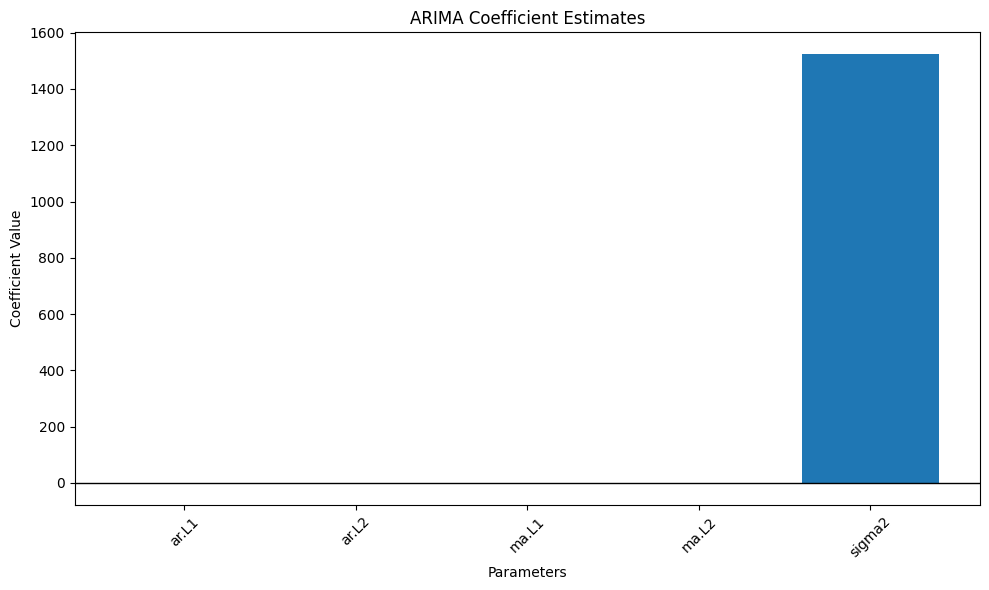

In [9]:
# ===============================
# 2. Coefficient bar plot
# ===============================

plt.figure(figsize=(10,6))
plt.bar(coef_df["Coefficient"], coef_df["Estimate"])
plt.axhline(0, color="black", linewidth=1)
plt.title("ARIMA Coefficient Estimates")
plt.xlabel("Parameters")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{save_dir}/01_ARIMA_Coefficient_Bar.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

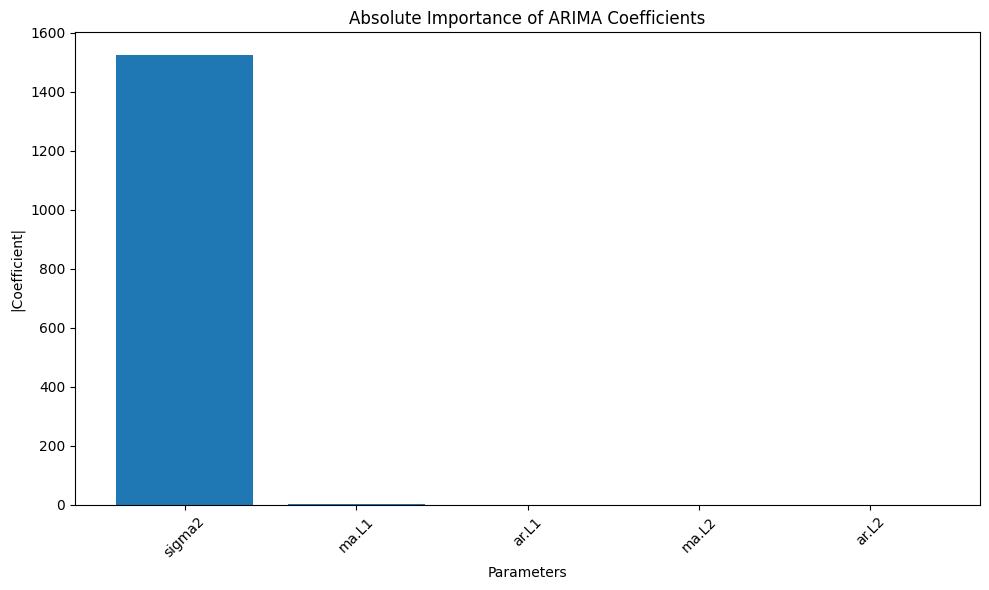

In [10]:
# ===============================
# 3. Absolute coefficient importance
# ===============================

coef_importance = coef_df.copy()
coef_importance["Absolute"] = coef_importance["Estimate"].abs()
coef_importance = coef_importance.sort_values(by="Absolute", ascending=False)

plt.figure(figsize=(10,6))
plt.bar(coef_importance["Coefficient"], coef_importance["Absolute"])
plt.title("Absolute Importance of ARIMA Coefficients")
plt.xlabel("Parameters")
plt.ylabel("|Coefficient|")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{save_dir}/02_ARIMA_Coefficient_Importance.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

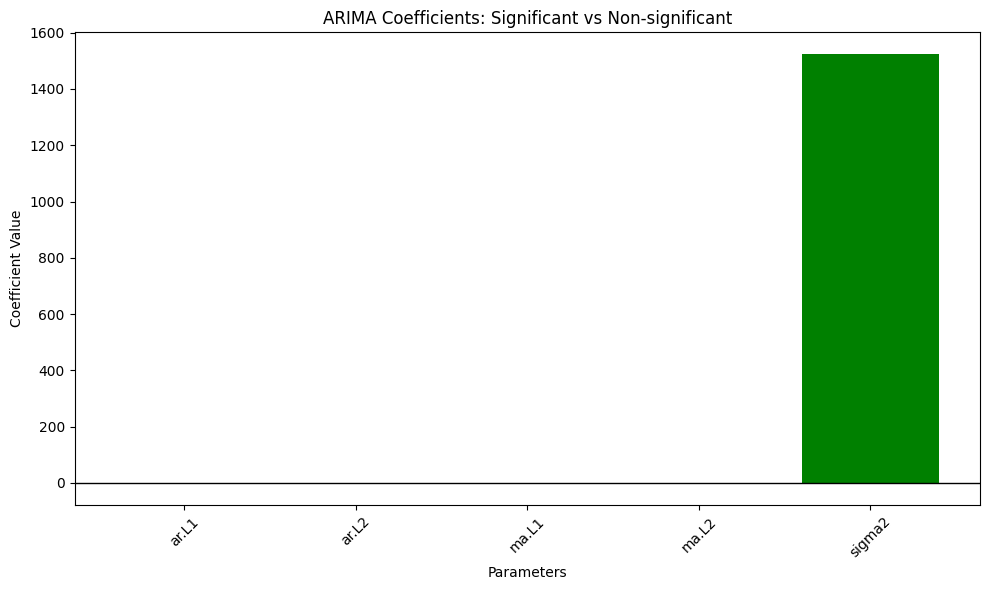

In [11]:
# ===============================
# 4. Significant vs non-significant coefficients
# ===============================

colors = ["green" if sig else "red" for sig in coef_df["Significant"]]

plt.figure(figsize=(10,6))
plt.bar(coef_df["Coefficient"], coef_df["Estimate"], color=colors)
plt.axhline(0, color="black", linewidth=1)
plt.title("ARIMA Coefficients: Significant vs Non-significant")
plt.xlabel("Parameters")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{save_dir}/03_ARIMA_Significant_Coefficients.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

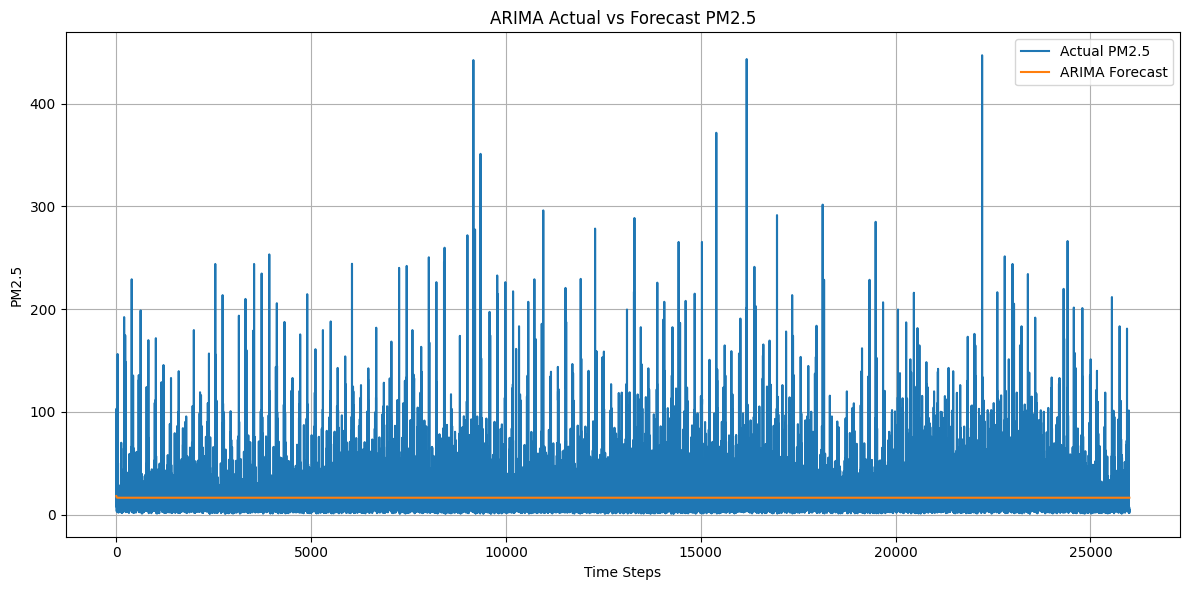

In [12]:
# ===============================
# 5. Actual vs forecast
# ===============================

plt.figure(figsize=(12,6))
plt.plot(y_true.values, label="Actual PM2.5")
plt.plot(y_pred.values, label="ARIMA Forecast")
plt.title("ARIMA Actual vs Forecast PM2.5")
plt.xlabel("Time Steps")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{save_dir}/04_Actual_vs_Forecast.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

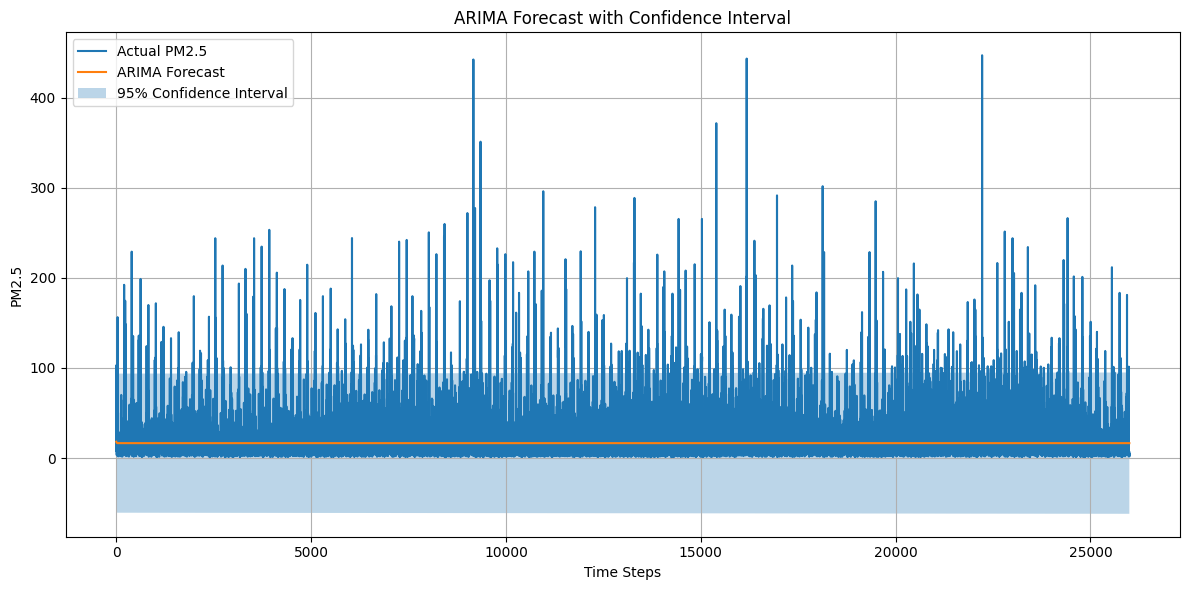

In [13]:
# ===============================
# 6. Forecast confidence interval
# ===============================

lower_bound = confidence_intervals.iloc[:, 0]
upper_bound = confidence_intervals.iloc[:, 1]

plt.figure(figsize=(12,6))
plt.plot(y_true.values, label="Actual PM2.5")
plt.plot(y_pred.values, label="ARIMA Forecast")

plt.fill_between(
    range(len(y_pred)),
    lower_bound.values,
    upper_bound.values,
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title("ARIMA Forecast with Confidence Interval")
plt.xlabel("Time Steps")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{save_dir}/05_Forecast_Confidence_Interval.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

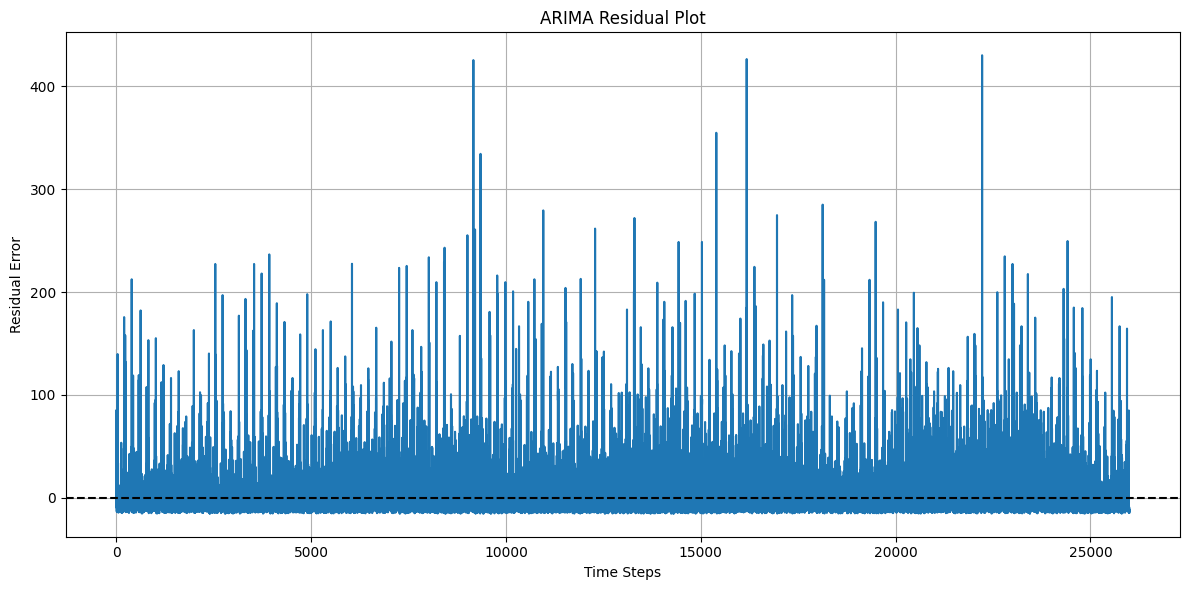

In [14]:

# ===============================
# 7. Residual plot
# ===============================

plt.figure(figsize=(12,6))
plt.plot(residuals.values)
plt.axhline(0, color="black", linestyle="--")
plt.title("ARIMA Residual Plot")
plt.xlabel("Time Steps")
plt.ylabel("Residual Error")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{save_dir}/06_Residual_Plot.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

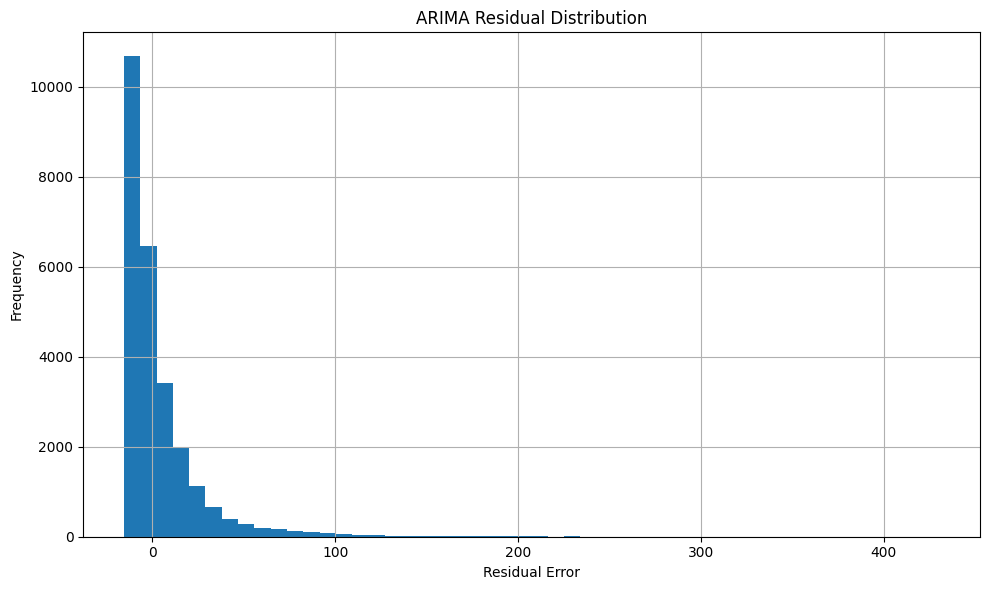

In [15]:
# ===============================
# 8. Residual distribution
# ===============================

plt.figure(figsize=(10,6))
plt.hist(residuals.dropna(), bins=50)
plt.title("ARIMA Residual Distribution")
plt.xlabel("Residual Error")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{save_dir}/07_Residual_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

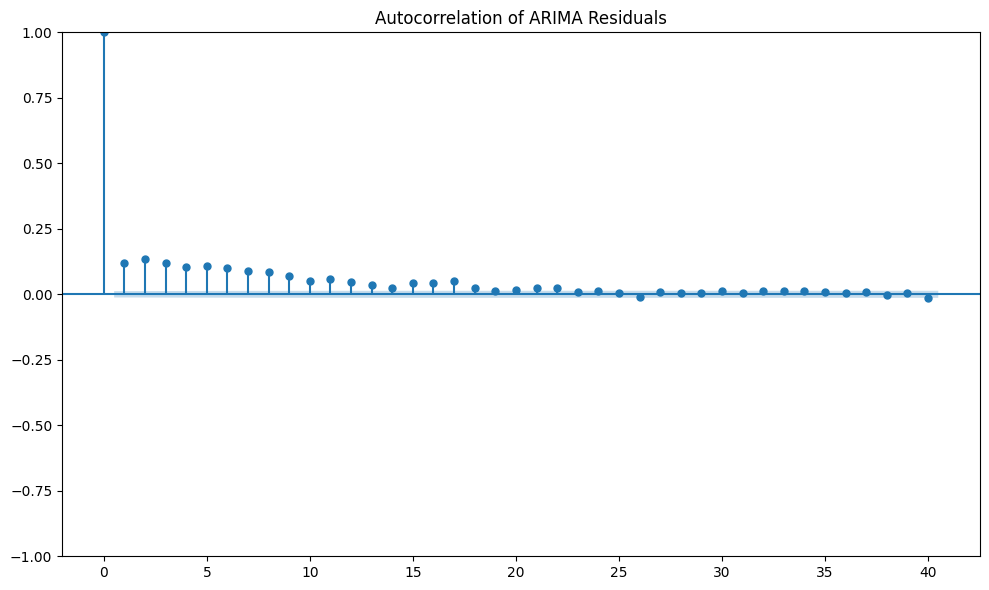

In [16]:
# ===============================
# 9. ACF plot of residuals
# ===============================

fig, ax = plt.subplots(figsize=(10,6))
plot_acf(residuals.dropna(), lags=40, ax=ax)
plt.title("Autocorrelation of ARIMA Residuals")
plt.tight_layout()
plt.savefig(f"{save_dir}/08_Residual_ACF.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

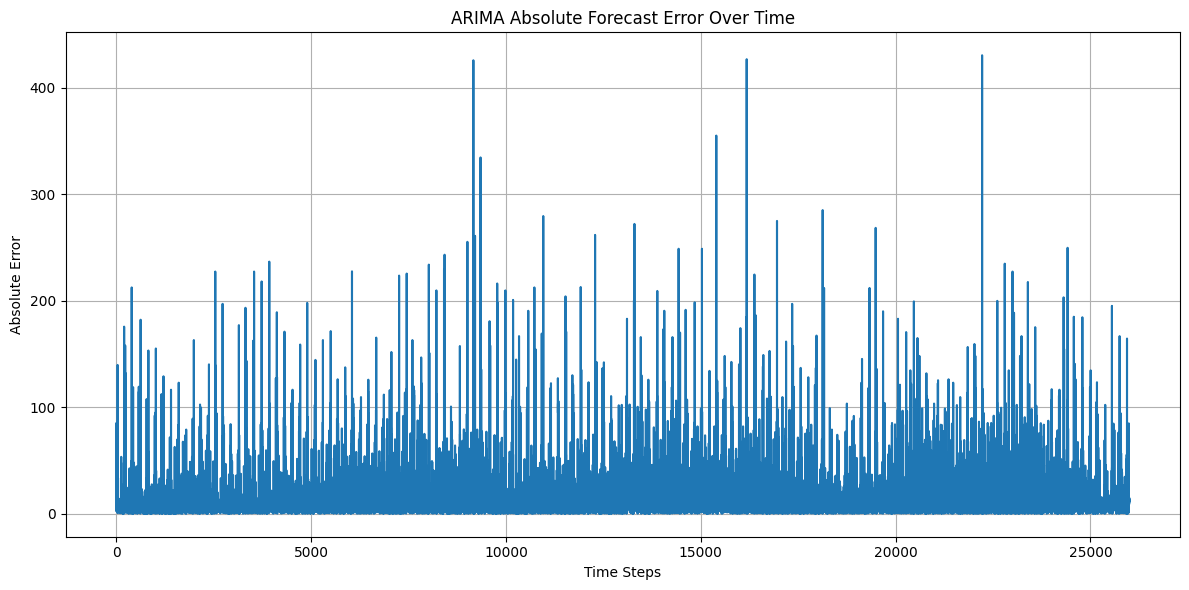

In [17]:
# ===============================
# 10. Absolute forecast error over time
# ===============================

plt.figure(figsize=(12,6))
plt.plot(absolute_error.values)
plt.title("ARIMA Absolute Forecast Error Over Time")
plt.xlabel("Time Steps")
plt.ylabel("Absolute Error")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{save_dir}/09_Error_Over_Time.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [18]:
# ===============================
# 11. Save metrics
# ===============================

metrics_df = pd.DataFrame({
    "Metric": ["MSE", "RMSE", "MAE", "R2", "Accuracy"],
    "Value": metrics_arima
})

metrics_df.to_csv(f"{save_dir}/ARIMA_Metrics.csv", index=False)

print("ARIMA Metrics")
display(metrics_df)

ARIMA Metrics


,Metric,Value
0,MSE,611.383499
1,RMSE,24.726170
2,MAE,13.851443
3,R2,-0.021180
4,Accuracy,-25.209179


In [20]:
# ===============================
# 12. ZIP and download all outputs
# ===============================

zip_path = "/content/ARIMA_XAI_All_Outputs.zip"

with zipfile.ZipFile(zip_path, "w") as zipf:
    for root, dirs, files_list in os.walk(save_dir):
        for file in files_list:
            file_path = os.path.join(root, file)
            zipf.write(file_path, arcname=file)

files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>